In [ ]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy import signal, interpolate
from scipy.signal import find_peaks
from scipy.fftpack import fft
import scipy.io.wavfile as wavfile
import matplotlib.mlab as mlab
from inputs import FreqFunctions, torqueStep, constant_func, ramp_func, ramp_func_dx, interpolate_func, random_walk, vel_tor_profile
#from csv_utils import Data
from data_utils import Data
from write_profile import Profile

In [2]:
# Profile([start_time, end_time], ctrl_freq = control_frequency_in_Hz, func_* = *_function, gains = [Kp, Ki, Kd], name = "profile_name")
STEP_TORQUE, STEP_REPS = [140/4, 140/2, 3*140/4, 140], 1
STEP_HOLD, STEP_COOL, STEP_RAMP = [0.2, 0.2, 0.15, 0.1], [1.0, 1.5, 1.5, 1.5], [0.09, 0.09, 0.09, 0.09]
STEP_DURATION, tSTEP_DUR = 2.0 * STEP_REPS * (sum(STEP_HOLD) + sum(STEP_COOL) + 2.0 * sum(STEP_RAMP)), 0.0
strTor, strHold, strCool, strRamp, strNTor = str(int(STEP_TORQUE[0])),str(STEP_HOLD[0]),str(STEP_COOL[0]),str(STEP_RAMP[0]),str(int(STEP_TORQUE[0])/35)

GAINS = [0.0, 0.0, 18.0]

ctrl_freq = 1000 # Hz -> 1000 = 10.921 s, 900 = 12.134 s, 800 = 13.671 s, 700 = 15.429 s, 600 = 21.873 s, 500 = 21.873 s,
ctrl_freq_step = 500 #   400 = 27.342 s, 300 = 36.457 s, 250 = 43.746 s, 200 = 54.683 s, 100 = 109.367 s, 50 = 218.734 s
CTRL_FREQS = np.asarray([1000, 900, 800, 700, 600, 500, 400, 300, 250, 200, 100, 50])

MAX_DURS = np.round(((32767-4)/(3*CTRL_FREQS)), decimals=3) # max dur for step profile in s
DURS = dict(zip(CTRL_FREQS, MAX_DURS))
MAX_DUR_STEP = np.round(((32767-4)/(3*ctrl_freq_step)), decimals=3) 
#assert(MAX_DUR >= STEP_DURATION)
if STEP_DURATION <= (MAX_DUR_STEP-7.0): tSTEP_DUR = STEP_DURATION + 7.0
else: tSTEP_DUR = MAX_DUR_STEP

MAX_NM, MAX_RAD_S = 140, 13.0 # Nm, rad/s
PosOffset, TorqueOffset = 0.0, 0.0

SINUSES, REP_DUR = 10, 4.0
SCALE_V, SCALE_T = 1.0, 0.6
RandomPhase, t_ramp = True, 0.1 # Hz, s

mySEED_RECIPIENT = 54
SEEDS = [42, 6769, 1064, 54, 91125, 12345]
SEED = SEEDS[0]
FREQS = [0.5, 25.0], [0.1, 7.0], [7.0, 17.0], [13.0, 25.0]
FREQ_RANGE = FREQS[0]

fStr = str(FREQ_RANGE[0]) + "," + str(FREQ_RANGE[1])
vStr, tStr = "_"+str(SCALE_V), "_"+str(SCALE_T)
for i in range(1,len(STEP_TORQUE)):
    strNTor += "," + str(int(STEP_TORQUE[i])/35)
    strTor += "," + str(int(STEP_TORQUE[i]))
    strHold += "," + str(STEP_HOLD[i])
    strCool += "," + str(STEP_COOL[i])
    strRamp += "," + str(STEP_RAMP[i])
stepStr = strTor+"_"+strHold+"_"+strCool+"_"+strRamp
stepStr_basic = "Tau_"+strNTor+"_V0"

MSineApp_t = "_"+str(SINUSES)+"_"+str(REP_DUR)
MSineApp_p = "_"+str(SINUSES)+"_"+str(REP_DUR)

Initializing Profile
13.0
Function: Position Multisine, Seed = 42, Freq. Range = [0.1, 10] Hz, Sinuses = 10, Duration = 10.92, Full Reps = 2.0 (+1 Half-Rep), Time/Rep = 4.0s, Max. Dur = 10.92s
Interval 1: Frequencies = [1.   7.75 6.75 4.5  4.5  8.75 1.   7.   2.25 1.  ], Amplitudes = [0.41099279 0.05303133 0.06088782 0.09133173 0.09133173 0.0469706
 0.41099279 0.05871326 0.18266346 0.41099279], Phases = [6.13001603 4.78238179 4.93898769 0.80496169 2.82985831 2.3297927
 5.82303616 4.04552386 5.16956368 2.78605358], Max Abs Vel (rad/s) = 13.0, Max Abs Vel (rpm) = 124.14085561167838
1 (4000,)
Interval 2: Frequencies = [4.75 2.5  1.   5.75 9.   0.75 8.75 8.5  3.   6.5 ], Amplitudes = [0.07492569 0.1423588  0.35589701 0.06189513 0.03954411 0.47452935
 0.04067394 0.04187024 0.11863234 0.05475339], Phases = [4.76320575 2.22755235 6.09907556 5.61164551 4.89072775 1.22295107
 2.93249455 0.27522718 0.96942947 4.29172315], Max Abs Vel (rad/s) = 13.0, Max Abs Vel (rpm) = 124.14085561167838
1 (4000

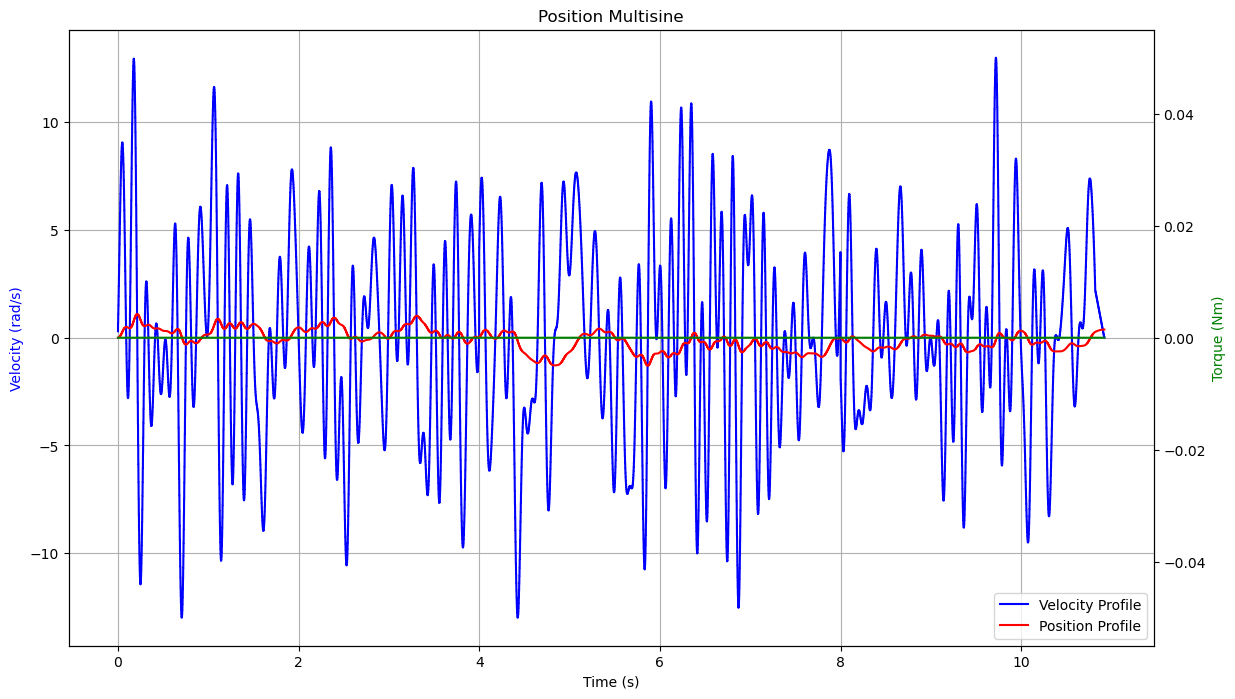

In [3]:
# ------------------------ Profiles ------------------------
# Dorator The Explorator
step_v = lambda t: vel_tor_profile(t, n_vel=20)[0]
step_t = lambda t: vel_tor_profile(t, n_vel=20)[1]
#dora = Profile([0,DURS[1000]], 1000, func_v = step_v, func_t = step_t, gains = GAINS, name = "Dora_"+stepStr_basic, folder = "")
#dora.writeProfile()
#dora.plot_profile(title = "Dora The Explorator")

zeros = lambda t: np.zeros_like(t)
fun = FreqFunctions(freq_range=FREQ_RANGE, seed=SEED, velmax=MAX_RAD_S, max_torque=MAX_NM, RandomPhase=True)
# Logarithmic Position Chirp
plc_ctrl_freq, fLog_p = 1000, [0.05, 5]
dlogChirp_p = lambda t: fun.LogPosChirp(t, freq_range=fLog_p, t_ramp = 0.1, vel = True)
#pLogChirp = Profile([0,DURS[plc_ctrl_freq]], plc_ctrl_freq, func_v = dlogChirp_p, func_t = zeros, gains = GAINS, name = "PLC_"+str(fLog_p[0]) + "," + str(fLog_p[1])+"_"+str(plc_ctrl_freq)+"Hz", folder = "Pos Log Chirp\\")
#pLogChirp.writeProfile() 

# Position Multisine
pms_seed, pms_ctrl_freq, fMSine_p, velScale = 42, 1000, [0.1,10], 1.0
multisine_dp = lambda t: fun.PosMultisine(t, REP_DUR, SINUSES, t_ramp = 0.1, seed = pms_seed, freq_range = fMSine_p, velmax=MAX_RAD_S*velScale, scaled = True, vel = True)
pMSine = Profile([0,DURS[pms_ctrl_freq]], pms_ctrl_freq, func_v = multisine_dp, func_t = zeros, gains = GAINS, name = "PMS_"+str(fMSine_p[0]) + "," + str(fMSine_p[1])+"_"+str(pms_seed)+MSineApp_p+"_"+str(int(MAX_RAD_S*velScale))+"rads"+str(pms_ctrl_freq)+"Hz", folder = "Pos Multisine\\")
pMSine.plot_profile(title = "Position Multisine")
#pMSine.writeProfile()

# Torque Multisine
tms_seed, tms_ctrl_freq, fMSine_t, torMax = 42, 1000, [0.5, 25], 45
multisine_t = lambda t: fun.TorqueMultisineRaw(t, REP_DUR, SINUSES, t_ramp = 0.1, seed = tms_seed, freq_range = fMSine_t, max_torque=torMax, scaled = False)
tMSine = Profile([0,DURS[tms_ctrl_freq]], tms_ctrl_freq, func_p = zeros, func_t = multisine_t, name = "TMS_"+str(fMSine_t[0]) + "," + str(fMSine_t[1])+"_"+str(tms_seed)+MSineApp_t+"_"+str(int(torMax))+"Nm"+str(tms_ctrl_freq)+"Hz", folder = "Torque Multisine\\")
#tMSine.writeProfile()

# Torque Step
step_t = lambda t: torqueStep(t, torque_seq=STEP_TORQUE, hold_seq=STEP_HOLD, cool_seq=STEP_COOL, ramp_times=STEP_RAMP) + np.zeros_like(t)
tStep = Profile([0,tSTEP_DUR], ctrl_freq_step, func_p = zeros, func_t = step_t, name = stepStr, folder = "Torque Step\\")
#tStep.writeProfile()
#tStep.plot_profile()

# Logarithmic Torque Chirp
torLim = 10
tlc_ctrl_freq, fLog_t, torScale = 1000, [0.5, 10], torLim/MAX_NM
logChirp_t = lambda t: fun.LogTorChirp(t, freq_range=fLog_t, tormax = MAX_NM*torScale)
tLogChirp = Profile([0,DURS[tlc_ctrl_freq]], tlc_ctrl_freq, func_p = zeros, func_t = logChirp_t, name = "TLC_"+str(fLog_t[0]) + "," + str(fLog_t[1])+"_"+str(int(MAX_NM*torScale))+"Nm"+str(tlc_ctrl_freq)+"Hz", folder = "Torque Log Chirp\\")
#tLogChirp.writeProfile()

# Torque and Velocity
vel_vals, tor_vals = [13.0, 12.0, 10.5, 6.0, 0.0], [0.0, 50.0, 100.0, 135.0, 140.0]

# Constant and vRamp
zero = Profile([0,5], ctrl_freq, func_v = zeros, func_t = zeros)
vMaxRamp = Profile([0,2], ctrl_freq =ctrl_freq, func_v = lambda t : ramp_func(0,MAX_RAD_S,t), func_t = zeros, name = "vMaxRamp")
# ----------------------------------------------------------

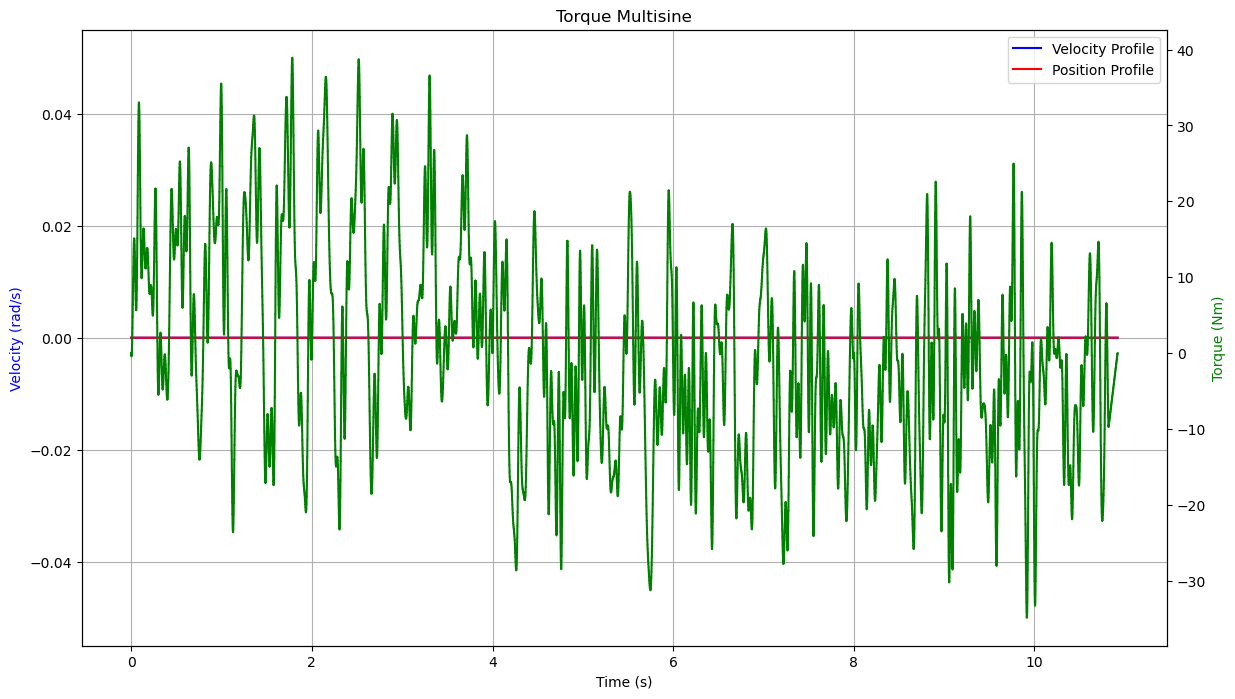

In [4]:
#tStep.writeProfile() #TORQUES_HOLDS_COOLS_RAMPS
#tLogChirp.writeProfile() #AMP_RAMP
#tMSine.writeProfile() 
#pLinChirp.writeProfile() 
#pLogChirp.writeProfile()
#pMSine.writeProfile() 
#vMaxRamp.writeProfile()

#tStep.plot_profile(title = "Torque Step") 
#tLogChirp.plot_profile(title = "Torque Log Chirp") 
tMSine.plot_profile(title = "Torque Multisine") 
#pLinChirp.plot_profile(title = "Position Linear Chirp")
#pLogChirp.plot_profile(title = "Position Log Chirp")
#pMSine.plot_profile(title = "Position Multisine") 

Initializing Profile
13.0
Function: Position Multisine, Seed = 42, Freq. Range = [0.1, 10] Hz, Sinuses = 10, Duration = 10.92, Full Reps = 2.0 (+1 Half-Rep), Time/Rep = 4.0s, Max. Dur = 10.92s
Interval 1: Frequencies = [1.   7.75 6.75 4.5  4.5  8.75 1.   7.   2.25 1.  ], Amplitudes = [0.20690143 0.02669696 0.03065206 0.04597809 0.04597809 0.02364588
 0.20690143 0.02955735 0.09195619 0.20690143], Phases = [6.13001603 4.78238179 4.93898769 0.80496169 2.82985831 2.3297927
 5.82303616 4.04552386 5.16956368 2.78605358], Max Abs Vel (rad/s) = 6.544442181715276, Max Abs Vel (rpm) = 62.49481937994565
1 (4000,)
Interval 2: Frequencies = [4.75 2.5  1.   5.75 9.   0.75 8.75 8.5  3.   6.5 ], Amplitudes = [0.04355819 0.08276057 0.20690143 0.03598286 0.02298905 0.27586857
 0.02364588 0.02434134 0.06896714 0.03183099], Phases = [4.76320575 2.22755235 6.09907556 5.61164551 4.89072775 1.22295107
 2.93249455 0.27522718 0.96942947 4.29172315], Max Abs Vel (rad/s) = 7.557575501681351, Max Abs Vel (rpm) = 

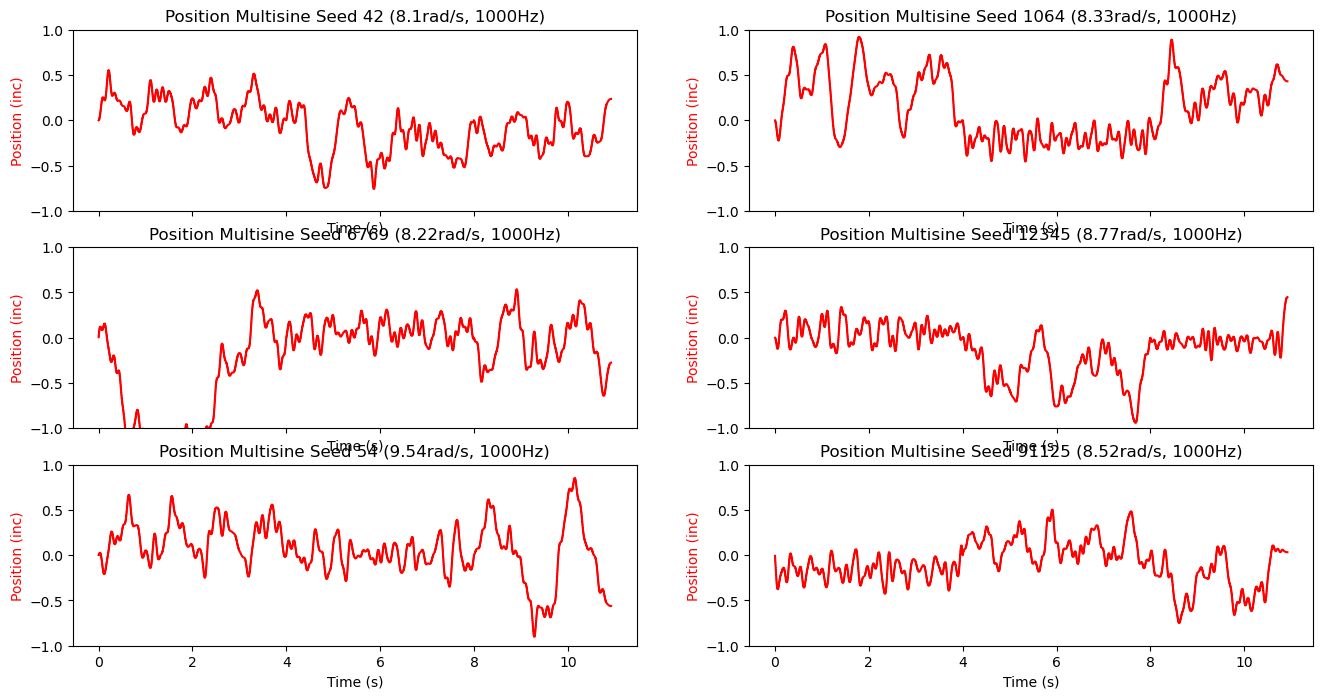

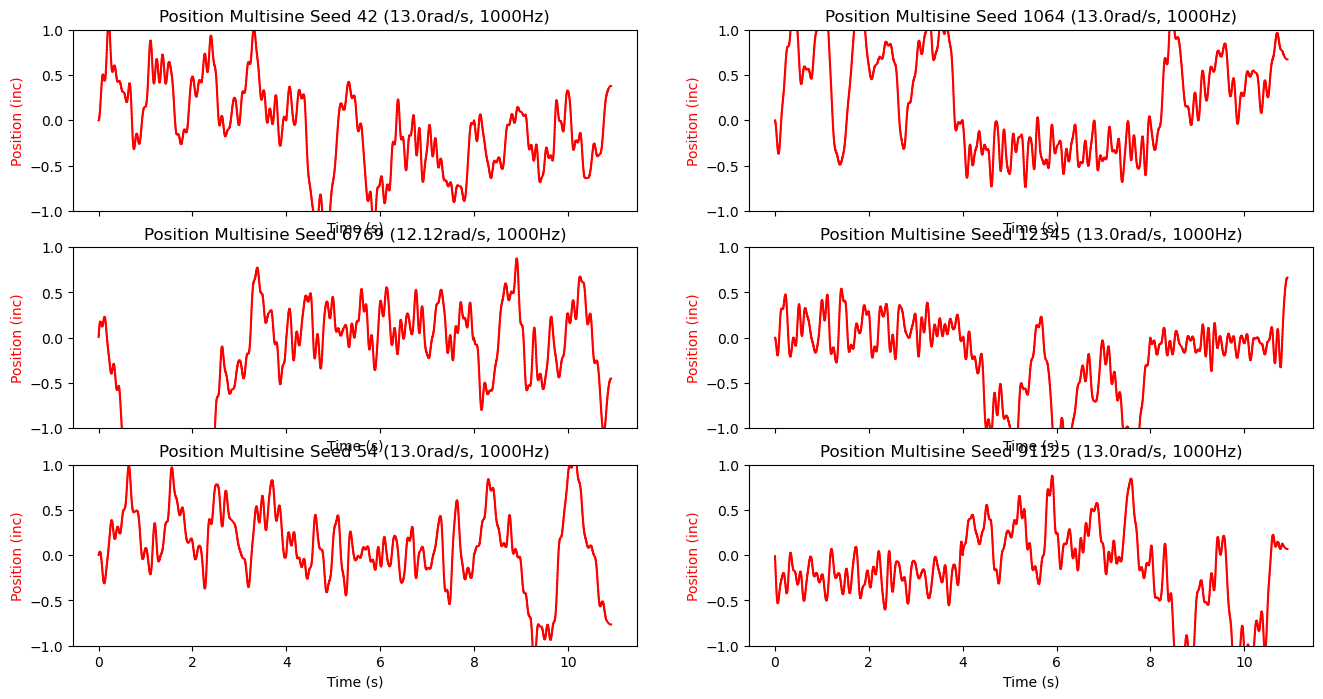

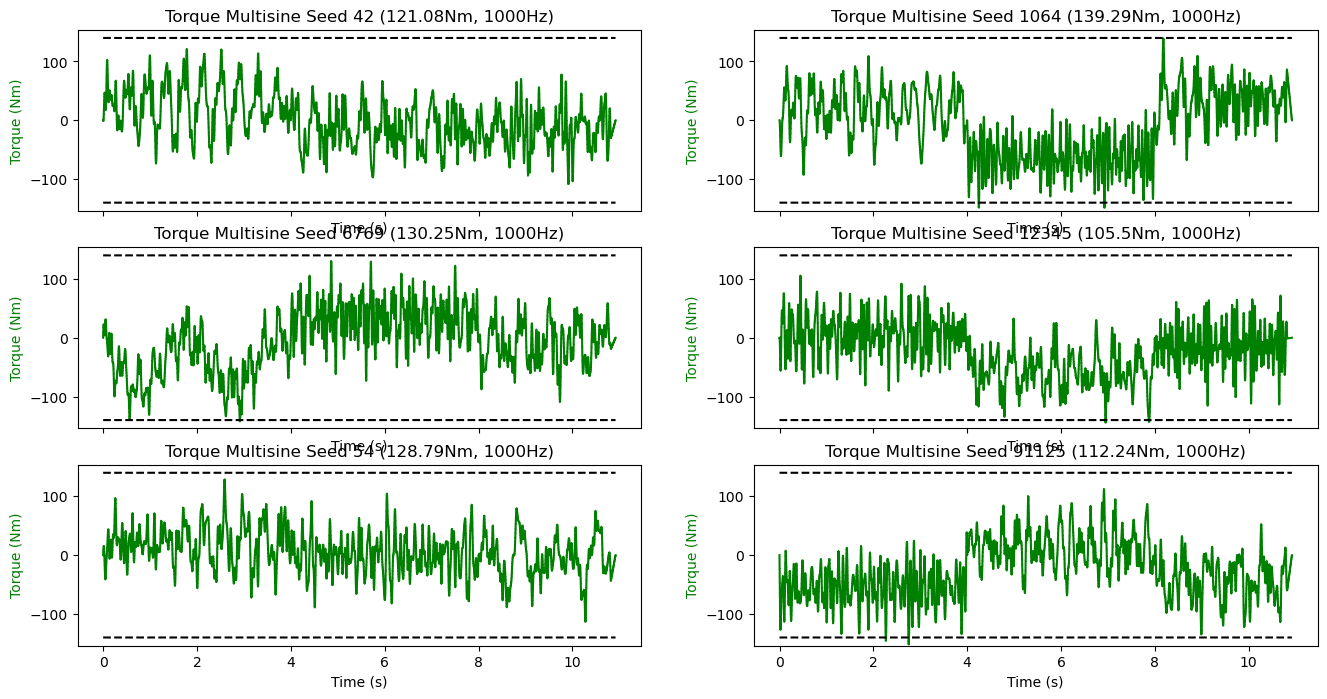

In [5]:
PlotAll = False
pMSineSeeds, pMSineFreqs = True, False
pLogChirpFreqs = False
tMSineSeeds, tMSineFreqs = True, False
tLogChirpFreqs = False
SEEDS = [42, 6769, 54, 1064, 12345, 91125]
FREQS = [[0.1, 25.0], [0.1, 7.0], [7.0, 17.0], [13.0, 25.0]]
CTRL_FREQS = [1000, 900, 800, 700, 600, 500, 400, 300, 250, 200, 100, 50]
ctrl_freq = 1000
MAX_DUR = DURS[ctrl_freq]

if PlotAll:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    tMSine.plot_subprofile(fig, axes, 0, 0, "Torque Multisine", vel = False)
    pMSine.plot_subprofile(fig, axes, 0, 1, "Position Multisine", tor = False)
    tLogChirp.plot_subprofile(fig, axes, 1, 0, "Torque Log Chirp", vel = False)
    pLogChirp.plot_subprofile(fig, axes, 1, 1, "Position Log Chirp", tor = False, pos_sep = True)
    tStep.plot_profile(title = "Torque Step")
if pMSineSeeds:
    fig, axes = plt.subplots(3, 2, figsize=(16, 8), sharex=True)
    for i in range(3):
        pMSine = Profile([0,MAX_DUR], ctrl_freq, func_v = lambda t: fun.PosMultisine(t, REP_DUR, SINUSES, t_ramp = 0.1, seed = SEEDS[i], freq_range = fMSine_p, vel = True), func_t = zeros, gains = GAINS, name = MSineApp_p+vStr+"_"+str(ctrl_freq)+"Hz"+"_"+str(SEEDS[i]), folder = "Pos Multisine\\")
        pMSine.plot_subprofile(fig, axes, i, 0, title = "Position Multisine Seed "+str(SEEDS[i]), pos_sep=True, tor = False)
        pMSine = Profile([0,MAX_DUR], ctrl_freq, func_v = lambda t: fun.PosMultisine(t, REP_DUR, SINUSES, t_ramp = 0.1, seed = SEEDS[i+3], freq_range = fMSine_p, vel = True), func_t = zeros, gains = GAINS, name = MSineApp_p+vStr+"_"+str(ctrl_freq)+"Hz"+"_"+str(SEEDS[i+3]), folder = "Pos Multisine\\")
        pMSine.plot_subprofile(fig, axes, i, 1, title = "Position Multisine Seed "+str(SEEDS[i+3]), pos_sep=True, tor = False)
    fig, axes = plt.subplots(3, 2, figsize=(16, 8), sharex=True)
    for i in range(3):
        pMSine = Profile([0,MAX_DUR], ctrl_freq, func_v = lambda t: fun.PosMultisine(t, REP_DUR, SINUSES, t_ramp = 0.1, seed = SEEDS[i], freq_range = fMSine_p, vel = True, scaled=True), func_t = zeros, gains = GAINS, name = MSineApp_p+vStr+"_"+str(ctrl_freq)+"Hz"+"_"+str(SEEDS[i]), folder = "Pos Multisine\\")
        pMSine.plot_subprofile(fig, axes, i, 0, title = "Position Multisine Seed "+str(SEEDS[i]), pos_sep=True, tor = False)
        pMSine = Profile([0,MAX_DUR], ctrl_freq, func_v = lambda t: fun.PosMultisine(t, REP_DUR, SINUSES, t_ramp = 0.1, seed = SEEDS[i+3], freq_range = fMSine_p, vel = True, scaled=True), func_t = zeros, gains = GAINS, name = MSineApp_p+vStr+"_"+str(ctrl_freq)+"Hz"+"_"+str(SEEDS[i+3]), folder = "Pos Multisine\\")
        pMSine.plot_subprofile(fig, axes, i, 1, title = "Position Multisine Seed "+str(SEEDS[i+3]), pos_sep=True, tor = False)
if pMSineFreqs:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    for i in range(2):
        pMSine = Profile([0,MAX_DUR], ctrl_freq, func_v = lambda t: fun.PosMultisine(t, REP_DUR, SINUSES, t_ramp = 0.1, seed = SEED, freq_range = FREQS[i], vel = True), func_t = zeros, gains = GAINS, name = "PMS_"+str(FREQS[i][0]) + "," + str(FREQS[i][1])+"_"+str(SEED)+"_"+str(SINUSES)+"_"+str(REP_DUR)+vStr+"_"+str(ctrl_freq)+"Hz"+"_"+str(FREQS[i][0]) + "," + str(FREQS[i][1]), folder = "Pos Multisine\\")
        pMSine.plot_subprofile(fig, axes, i, 0, title = "Position Multisine Freq Range "+str(FREQS[i][0]) + "," + str(FREQS[i][1]), pos_sep=True, tor = False)
        pMSine = Profile([0,MAX_DUR], ctrl_freq, func_v = lambda t: fun.PosMultisine(t, REP_DUR, SINUSES, t_ramp = 0.1, seed = SEED, freq_range = FREQS[i+2], vel = True), func_t = zeros, gains = GAINS, name = "PMS_"+str(FREQS[i+2][0]) + "," + str(FREQS[i+2][1])+"_"+str(SEED)+"_"+str(SINUSES)+"_"+str(REP_DUR)+vStr+"_"+str(ctrl_freq)+"Hz"+"_"+str(FREQS[i+2][0]) + "," + str(FREQS[i+2][1]), folder = "Pos Multisine\\")
        pMSine.plot_subprofile(fig, axes, i, 1, title = "Position Multisine Freq Range "+str(FREQS[i+2][0]) + "," + str(FREQS[i+2][1]), pos_sep=True, tor = False)
if tMSineSeeds:
    fig, axes = plt.subplots(3, 2, figsize=(16, 8), sharex=True)
    for i in range(3):
        tMSine = Profile([0,MAX_DUR], ctrl_freq, func_p = zeros, func_t = lambda t: fun.TorqueMultisineRaw(t, REP_DUR, SINUSES, t_ramp = 0.1, seed = SEEDS[i], freq_range = fMSine_t, scaled = False), name = MSineApp_t+tStr+"_"+str(ctrl_freq)+"Hz"+"_"+str(SEEDS[i]), folder = "Torque Multisine\\")
        tMSine.plot_subprofile(fig, axes, i, 0, title = "Torque Multisine Seed "+str(SEEDS[i]), vel=False)
        tMSine = Profile([0,MAX_DUR], ctrl_freq, func_p = zeros, func_t = lambda t: fun.TorqueMultisineRaw(t, REP_DUR, SINUSES, t_ramp = 0.1, seed = SEEDS[i+3], freq_range = fMSine_t, scaled = False), name = MSineApp_t+tStr+"_"+str(ctrl_freq)+"Hz"+"_"+str(SEEDS[i+3]), folder = "Torque Multisine\\")
        tMSine.plot_subprofile(fig, axes, i, 1, title = "Torque Multisine Seed "+str(SEEDS[i+3]), vel=False)


In [6]:
path = "C:\\Users\\maxma\\OneDrive\\ETH\\Bachelors_Thesis\\Data Collection\\"
fName = "35_4_1_0.9" #name of the .csv file output by the motor controller
data = Data(fName, path = path)
data.importData() #import the data from the .csv file, apply unit conversions and store in a pandas dataframe
data.exportData() #export the data
#data.raw.head()

AssertionError: Input folder does not exist: C:\Users\maxma\OneDrive\ETH\Bachelors_Thesis\Data Collection\35_4_1_0.9

In [ ]:
# inputs: data (1D array), f_s (sampling frequency in Hz), f_cutoff (cutoff frequency in Hz), order (order of the Butterworth filter)
# Apply the causal IIR filter to the input data to obtain the filtered signal (Butterworth low pass filter)
def lp_filt_des (data, f_s, f_cutoff, order):
    Wn = f_cutoff
    b, a = signal.iirfilter(order, Wn, rp=None, rs=None, btype='lowpass', analog=False, ftype='butter', output='ba', fs=f_s)
    data_filt = signal.lfilter(b, a, data)
    return data_filt

In [ ]:
# Estimate the sampling rate from the recorded data, low pass filter the main torque signals, and plot them together for comparison
#fs = 1/np.mean(np.diff(data.df.Time)) # Estimate the sampling frequency from the average time step of the recorded data
fs = 1000.0 # sampling freq [Hz]
f_cut = 400 # Hz

# apply LP filter on...
filt_tor = lp_filt_des(data.df.torAct, fs, f_cut, 1) #...measured torque signal
filt_torEst = lp_filt_des(data.df.torEst, fs, f_cut, 1) #...estimated torque signal
filt_torDem = lp_filt_des(data.df.torDes, fs, f_cut, 1) #...commanded torque signal 
torErr = data.df.torAct-data.df.torEst
filt_torErr = filt_tor - filt_torEst

# Plot the filtered torque signals versus time
fig, ax = plt.subplots(1, figsize = (16, 8))
ax.step(data.df.t, filt_torEst, label = 'Torque Est', c='r')
ax.step(data.df.t, filt_tor, label = 'Torque', c='b')
#ax.step(data.df.t, filt_torDem, label = 'Torque Cmd', c='g')
#ax.step(data.df.t, torErr, label = 'Torque Estimation Error', c = 'r')
#ax.step(data.df.t, filt_torErr, label = 'Filtered Torque Estimation Error', c = 'b')
ax.set_ylabel('Torque (Nm)', c='b')
ax.set_xlabel('Time (s)')
ax.legend()

plt.title(fName)# Use the current test name as the plot title

In [ ]:
data.df = data.df[data.df.t > 0.1] # Remove the first 0.1 s of recorded data to discard startup/transient samples
#gwalker = pyg.walk(df)
#print(data.df)
fig, ax = plt.subplots(1, figsize = (16, 8))
#ax.step(data.df.t, data.df.torEst, label = 'Torque Est', c='r')

#plot torque, velocity and position profiles from the test data, with torque on left y-axis and velocity and position on right y-axis, as step functions due to implementation of motor controller
ax.step(data.df.t, data.df.torEst, label = 'Torque Est', c='g')
ax.step(data.df.t, -1*data.df.torDes, label = 'Torque Cmd', c='orange')
ax.step(data.df.t, data.df.torAct, label = 'Torque Measured', c='b')
ax.step(data.df.t, data.df.torAct-data.df.torEst, label = 'Torque Estimation Error', c='r')
ax.set_ylabel('Torque (mNm)', c='b')
#ax.set_ylim((-140000,140000))
#ax.step(data.df.t, data.df.velDes, label = 'Velocity Command', c='g')
#ax.step(data.df.t, data.df.velAct, label = 'Velocity Measured', c='b')
#ax.step(data.df.t, data.df.velAct-data.df.velDes, label = 'Velocity Error', c='r')
#ax.set_ylabel('Velocity (rad/s)', c='b')
#ax.set_xlim((3.5,4.5))

#estimate acceleration by differentiating velocity command and multiplying by control frequency (2500 Hz) to convert from discrete difference to derivative, and prepend 0 to maintain same length as other data series
accel_est = np.insert(np.diff(data.df.velDes)*2500,0,0) 

ax.set_xlabel('t (s)')
ax.legend()
ax.grid()
plt.title(fName)